### Monte Carlo method root finding

Find the root $x_0 \in [0, 1]$ of the function $e^x - 3 \, x$ using a Monte Carlo approach

In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
f = lambda x: np.exp(x) - 3.0 * x # e^x - 3x = 0

In [3]:
def monte_carlo_root(f, a, b, N): # Quick Monte Carlo method

    x = np.random.uniform( # N points uniformly distributed in [a, b]
        low = a,
        high = b,
        size = N
    )

    fx = f(x)
    ind = np.argmin(np.abs(fx)) # Index of the root
    root = x[ind]
    residual = fx[ind]

    return root, residual # Returns the root and the residual f(root)

In [4]:
a, b = 0.0, 1.0 # [0, 1]
N = 10_000 # Number of points

In [5]:
monte_carlo_root(f, a, b, N), monte_carlo_root(f, a, b, N), monte_carlo_root(f, a, b, N) # 3 independent runs

((np.float64(0.6190247304468152), np.float64(4.177835814855868e-05)),
 (np.float64(0.6190709156390363), np.float64(-1.1003979765611405e-05)),
 (np.float64(0.6189364262937026), np.float64(0.00014270700488294707)))

To estimate an error, let's run 1000 times the algorithm. Take mean and the standard deviation

In [6]:
M = 1_000 # Numbers of runs
roots = np.array([monte_carlo_root(f, a, b, N) for _ in range(M)]) # Roots array
roots

array([[ 6.19077536e-01, -1.85694944e-05],
       [ 6.19031207e-01,  3.43764726e-05],
       [ 6.18904473e-01,  1.79231695e-04],
       ...,
       [ 6.19036450e-01,  2.83844207e-05],
       [ 6.19137870e-01, -8.75151247e-05],
       [ 6.19062815e-01, -1.74655702e-06]], shape=(1000, 2))

In [7]:
mean, std = np.mean(roots[:, 0]), np.std(roots[:, 0]) # Results
mean, std

(np.float64(0.6190655999313079), np.float64(7.424562750848268e-05))

We've found:

$$
    0.61906 \pm 0.00007 \, (0.01 \%)
$$

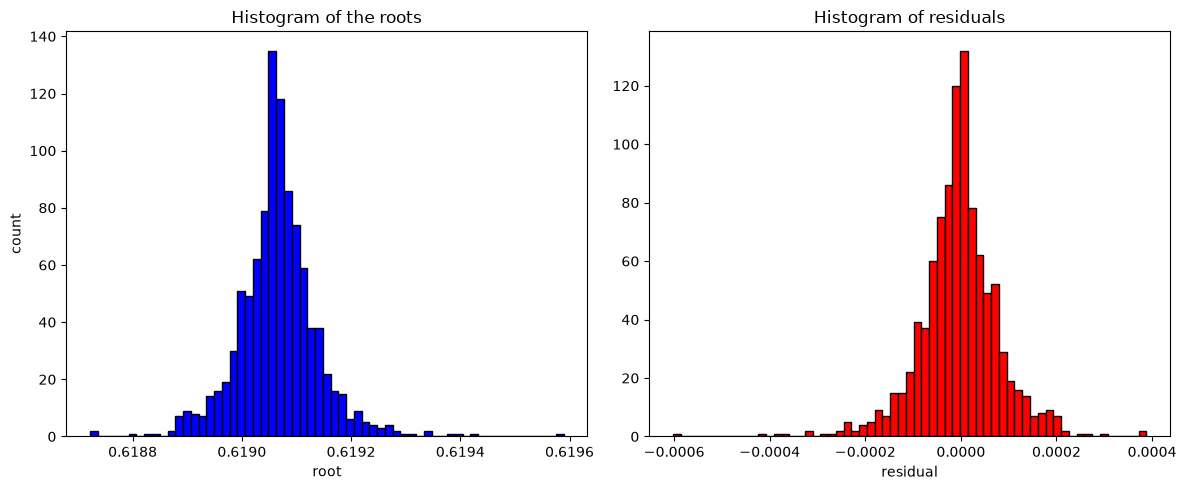

In [8]:
# Plotting
fig, (ax1, ax2) = plt.subplots(1, 2, figsize = (12, 5))

# Histogram of roots (left)
ax1.hist(roots[:, 0], bins = 'auto', density = False, color = 'blue', edgecolor = 'black')
ax1.set_title("Histogram of the roots")
ax1.set_xlabel("root")
ax1.set_ylabel("count")

# Histogram of residuals (right)
ax2.hist(roots[:, 1], bins='auto', density = False, color = 'red', edgecolor = 'black')
ax2.set_title("Histogram of residuals")
ax2.set_xlabel("residual")

plt.tight_layout()
plt.show()